# **EQ02 — Volatilité locale de Dupire : de la surface implicite à la diffusion**

La **volatilité locale** $\sigma_{\rm loc}(S,t)$ de Dupire est le pont entre une **surface de
volatilité implicite** (statique, cotée aujourd'hui) et une **dynamique** du sous-jacent capable de
repricer *toutes* les vanilles simultanément. Ce notebook déroule trois temps :

1. **Le modèle** — pourquoi la vol locale est l'**unique** diffusion *déterministe* cohérente avec la
   surface, et la formule de Dupire/Gatheral qui l'extrait.
2. **La calibration de surface** — le cœur du sujet : Dupire consomme des **dérivées** de la surface ;
   on explique *lesquelles*, *pourquoi les différences finies sont instables*, et on passe en revue nos
   interpolateurs (bicubique, RBF, **SVI**, **SSVI**) — formules, paramètres, contraintes, dérivées
   analytiques, et le piège de l'**arbitrage calendaire**.
3. **Le pricing** — simulation Monte-Carlo par schéma d'Euler, convergence vers le prix de référence,
   et vérification que la vol locale **reprice bien** la surface de départ.

In [1]:
from datetime import date, timedelta

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from JR_PRICER.market_data.quote import Quote
from JR_PRICER.market_data.underlying import Underlying
from JR_PRICER.utils.day_count import DayCounter
from JR_PRICER.curves.temporal.discount import FlatDiscountCurve
from JR_PRICER.curves.forward.analytic_forward import AnalyticForwardCurve

from JR_PRICER.instruments.derivatives.equity.base import OptionType
from JR_PRICER.instruments.derivatives.equity.european_option import EuropeanOption

from JR_PRICER.pricing.model.heston import HestonModel
from JR_PRICER.pricing.model.local_vol import LocalVolModel
from JR_PRICER.pricing.model.discretization.CIR.base import (
    CIRDiscretizationSchemeEuler, EulerDiscretizationConvention)
from JR_PRICER.pricing.engine.fourier_carr_madan import FourierCarrMadanEngine
from JR_PRICER.pricing.engine.monte_carlo import MCEngine
from JR_PRICER.pricing.implied_vol_calculator import ImpliedVolCalculator

from JR_PRICER.curves.vol_smile.volsmile import VolSmile
from JR_PRICER.curves.vol_smile.moneyness_convention import AbsoluteStrike
from JR_PRICER.curves.interpolators_1D.log_linear import LogLinearInterpolator1D
from JR_PRICER.surfaces.vol_surface.volsurface import VolSurface
from JR_PRICER.surfaces.vol_surface.theta_curve import ThetaCurve
from JR_PRICER.surfaces.vol_surface.interpolators_2D.SVI import SVIInterpolator
from JR_PRICER.surfaces.vol_surface.interpolators_2D.SSVI import SSVIInterpolator
from JR_PRICER.surfaces.vol_surface.interpolators_2D.bi_cubic import BiCubicInterpolator
from JR_PRICER.surfaces.vol_surface.interpolators_2D.RBF import RBFInterpolator2D

from JR_PRICER.viz.surfaces import plot_surface

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
C_IMP, C_LOC, C_MKT, C_ACC = '#1565C0', '#E65100', '#C62828', '#2E7D32'
print('Imports OK')

Imports OK


## 0. Mise en place : imports & surface de marché

On se donne un marché *fictif mais réaliste* : un **Heston** « vrai » (paramètres cachés au calibreur) qui
sert à **générer** une surface de vol implicite sans biais de pricing (via Fourier/Carr-Madan). C'est
exactement la surface du notebook 05. La vol locale sera ensuite extraite de cette surface et devra,
en toute logique, ramener vers ce Heston.

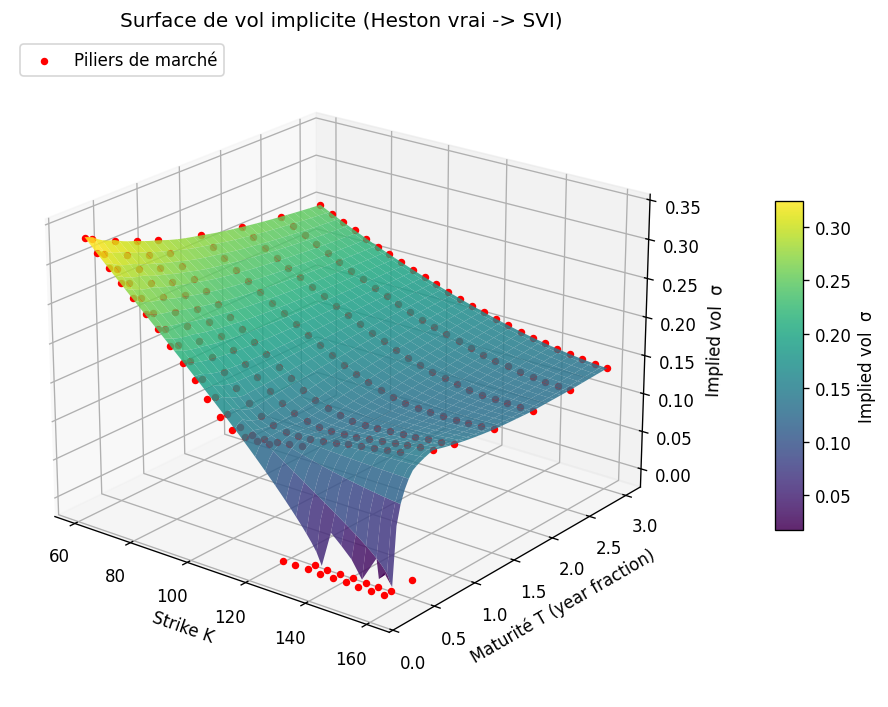

Surface calibrée : VolSurface(n_smiles=9, interp=SVIInterpolator) | LocalVolModel(discount=FlatDiscountCurve(rate=0.03, ref=2024-01-15))


In [2]:
# --- Marché : Heston vrai -> surface de vol implicite (smiles en strike absolu) ---
REF = date(2024, 1, 15)
DC = DayCounter('act/365')
def in_days(n): return REF + timedelta(days=int(n))

S0, R = 100.0, 0.03
spot = Quote(S0, name='EQ')
disc = FlatDiscountCurve(R, DC, REF)
fwd = AnalyticForwardCurve(spot, disc, dividend_yield=0.0)
und = Underlying('EQ', spot, fwd, vol_provider=None)

TRUE = dict(kappa=1.5, theta=0.04, sigma_v=0.5, rho=-0.7, v0=0.035)
heston = HestonModel(discount_curve=disc, **TRUE)
fourier = FourierCarrMadanEngine(n=12)
ivc = ImpliedVolCalculator(disc)

surf_days = [60, 91, 182, 273, 365, 548, 730, 912, 1095]
strikes = np.linspace(60, 160, 25)
smiles = []
for d in surf_days:
    calls = [EuropeanOption(und, float(K), REF, in_days(d), OptionType.CALL) for K in strikes]
    iv = ivc.calculate_implied_vol(calls, fourier.price(calls, heston))
    smiles.append(VolSmile(strikes, iv, LogLinearInterpolator1D(), in_days(d), AbsoluteStrike()))

surface = VolSurface(smiles, REF, DC, SVIInterpolator(fwd), forward_curve=fwd)
surface.calibrate_interpolator()
und.vol_provider = surface
lv = LocalVolModel(disc)

with np.errstate(invalid='ignore'):   # coins extrapolés (w<0) -> NaN transparent dans le plot
    ax = plot_surface(surface, with_interpolation=True, show_pillars=True)
ax.set_title('Surface de vol implicite (Heston vrai -> SVI)'); ax.view_init(elev=22, azim=-52)
plt.tight_layout(); plt.show()
print('Surface calibrée :', surface, '|', lv)

**On remarque** trois traits de cette surface Heston :

- un **skew negatif** ($\rho=-0.7$) : la vol implicite decroit avec le strike (les puts OTM /
  calls ITM cotent une vol plus elevee) ;
- une **structure par terme** qui s'aplatit et se redresse vers $\sqrt{\theta}=20\%$ a mesure que $T$
  grandit : la variance instantanee $v_0=3.5\%$ relaxe vers sa moyenne long-terme $\theta=4\%$ ;
- un **coin OTM court terme troue** (transparent) : la, les calls tres hors-monnaie valent si peu que
  leur prix Fourier tombe sous le **plancher numerique de Carr-Madan** (l'inversion de vol implicite
  renvoie $0$), et l'extrapolation SVI y donne une variance totale negative -> `NaN` masque au trace.
  Ce n'est **pas** une limite de Heston (qui price parfaitement ces options, de valeur simplement
  infime) mais du **moteur Fourier**. Ces points sont dans une aile que le Monte-Carlo n'atteint
  jamais : ils n'affectent pas le pricing. On y revient au **&sect;2.6**, mecanisme detaille au
  **notebook 05, &sect;3.5** (bug #2).

## **1. Le modèle de volatilité locale de Dupire**

### **1.1 Motivation**
Black-Scholes suppose une volatilité constante : un seul $\sigma$ ne peut pas reproduire à la fois
le smile (variation en strike) et sa structure par terme (variation en maturité). On cherche donc une
**diffusion unique** qui, par construction, reprice **toutes** les options vanille cotées.

### **1.2 La dynamique**
Dupire (1994) propose de garder une diffusion à **un seul facteur**, mais de rendre la volatilité
**fonction déterministe** de l'état $(S,t)$ :
$$
dS_t = (r-q)\,S_t\,dt + \sigma_{\rm loc}(S_t,t)\,S_t\,dW_t.
$$
Contrairement à Heston, il n'y a **pas** de source d'aléa supplémentaire : $\sigma_{\rm loc}$ est une
*surface figée*, pas un processus.

### **1.3 Unicité**
C'est le point clé. À partir de prix d'appels $C(K,T)$ **sans arbitrage**, la formule de Dupire donne
$$
\sigma_{\rm loc}^2(K,T)=\frac{\partial_T C}{\tfrac12 K^2\,\partial_{KK} C},
$$
où $\partial_{KK}C$ est — à l'actualisation près — la **densité risque-neutre** de $S_T$
(*Breeden-Litzenberger*). Cette surface est **entièrement déterminée** par les prix : dans la classe des
diffusions **déterministes markoviennes à un facteur**, la vol locale est **l'unique** modèle
compatible avec la surface.

> **Attention à la nuance.** *Beaucoup* de modèles à volatilité **stochastique** (Heston, etc.) peuvent
> coller à la même surface — l'unicité ne vaut **que** dans la classe déterministe. Deux modèles calés
> sur la même surface peuvent ensuite **diverger sur un exotique** : c'est tout l'objet du notebook 07.

### **1.4 La formule implémentée (Gatheral)**
Numériquement on travaille en **variance totale** $w=\sigma_{\rm impl}^2\,T$ et **log-moneyness**
$y=\ln(K/F)$. La formule équivalente (Gatheral) utilisée par `LocalVolModel.sigma_loc` est
$$
\sigma_{\rm loc}^2=\frac{\partial_T w}
{1-\dfrac{y}{w}\partial_y w+\tfrac14\!\Big(-\tfrac14-\tfrac1w+\tfrac{y^2}{w^2}\Big)(\partial_y w)^2+\tfrac12\,\partial_{yy}w}.
$$
Le **numérateur** est la dérivée **calendaire** $\partial_T w$ ; le **dénominateur** ne dépend que des
dérivées en strike. La formule dégénère en $t=0$ (termes $1/w$) : l'implémentation applique un
**plancher** `T_FLOOR` $=10^{-4}$.

### **1.5 Une propriété profonde (Gyöngy)**
La vol locale n'est pas qu'un artifice de calibration. Le théorème de **Gyöngy** montre que la variance
locale est l'**espérance conditionnelle de la variance instantanée** du *vrai* modèle :
$$
\sigma_{\rm loc}^2(K,t)=\mathbb{E}^{\mathbb Q}\!\big[\,v_t \;\big|\; S_t=K\,\big].
$$
Autrement dit, si le marché est un Heston de variance $v_t$, la vol locale extraite de sa surface est la
moyenne de $v_t$ *conditionnellement au niveau du spot*. On le **vérifie numériquement** en §3.3.

## **2. Calibration de surface : la stabilité des dérivées**

La formule de Dupire est un **quotient de dérivées** de la surface. Sa qualité tient donc entièrement
à la régularité de la surface interpolée. C'est le cœur pratique de la vol locale.

### **2.1 Quelles dérivées, et pourquoi elles sont délicates**
- $\partial_{KK}w$ (dénominateur) $\leftrightarrow$ **densité** risque-neutre. Une densité valide est
  $\ge 0$ : c'est la condition de **non-arbitrage papillon**. Si $\partial_{KK}$ devient « trop
  négatif », la densité passe sous zéro et le dénominateur de Dupire $\le 0$ — `LocalVolModel` **lève**
  alors une erreur d'arbitrage.
- $\partial_T w$ (numérateur) $\leftrightarrow$ **arbitrage calendaire**. La variance totale doit
  **croître** avec la maturité ($\partial_T w\ge 0$). Sinon $\sigma_{\rm loc}^2<0$ : vol locale
  *imaginaire* (`NaN`).

Deux dérivées « fragiles » (une seconde en strike, une première en temps) au **dénominateur** et au
**numérateur** : la moindre irrégularité de la surface s'y amplifie.

### **2.2 Pourquoi les différences finies (FF) sont instables**
Une dérivée seconde par différence finie se comporte comme $\sim \text{bruit}/h^2$ : elle **amplifie**
le bruit de marché. Sur un smile légèrement bruité, $\partial_{KK}w$ obtenu par FF **oscille**, peut
devenir **négatif** (densité < 0), et rend $\sigma_{\rm loc}$ indéfinie. La parade : une surface
**paramétrique, lisse et sans arbitrage**, dont on tire des **dérivées analytiques** (stables par
construction). On l'illustre ci-dessous.

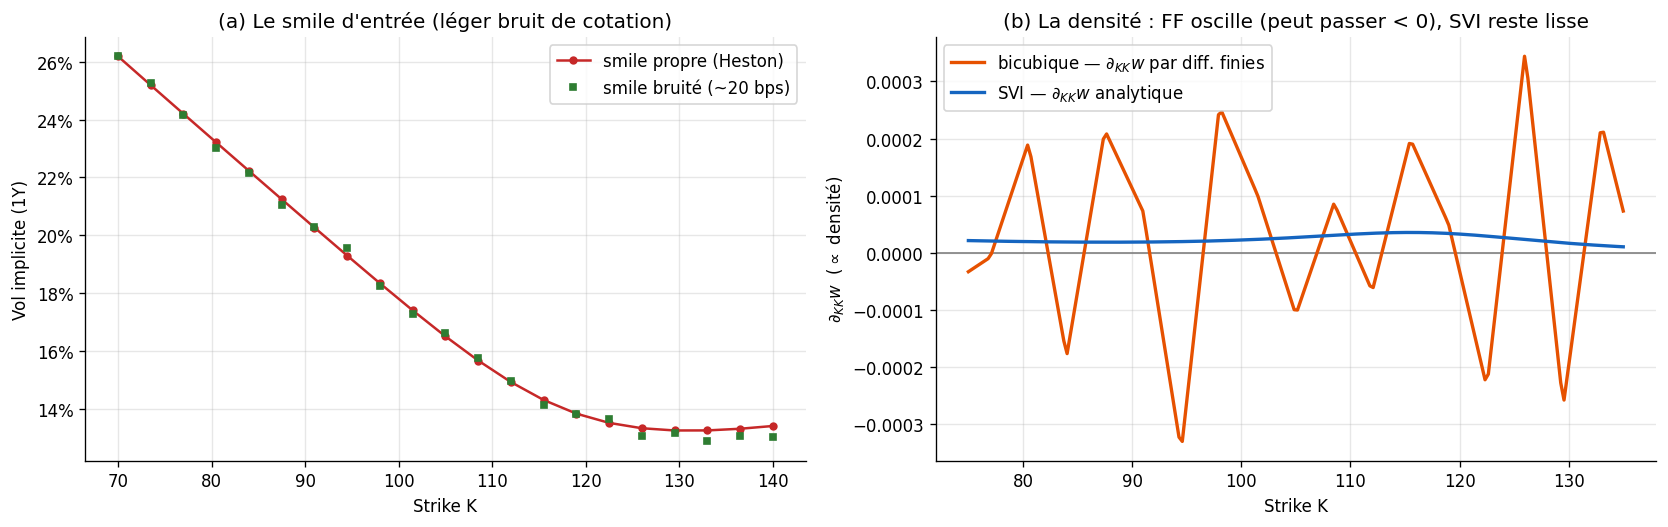

min d2w/dK2  bicubique(FF) = -0.00033  | SVI(analytique) = 1e-05


In [3]:
# DÉMO : dérivée seconde d'un smile légèrement bruité — FF (bicubique) vs analytique (SVI).
rng = np.random.default_rng(7)
T_demo = 1.0
Fd = fwd.forward(T_demo)
K_demo = np.linspace(70, 140, 21)
# smile 'marché' bruité (Heston + petit bruit de cotation)
calls_demo = [EuropeanOption(und, float(K), REF, in_days(365), OptionType.CALL) for K in K_demo]
iv_clean = np.asarray(ivc.calculate_implied_vol(calls_demo, fourier.price(calls_demo, heston)))
iv_noisy = iv_clean + rng.normal(0, 2e-3, size=iv_clean.shape)   # ~20 bps de bruit

# (a) surface bicubique fittée sur le smile bruité -> d2w/dK2 par FF de la base
# (RectBivariateSpline exige >= 4 maturités ; la maturité 365 porte le smile bruité)
mats_dup = [182, 365, 730, 1095]
smiles_dup = []
for d in mats_dup:
    c = [EuropeanOption(und, float(K), REF, in_days(d), OptionType.CALL) for K in K_demo]
    ivc_ = np.asarray(ivc.calculate_implied_vol(c, fourier.price(c, heston)))
    if d == 365:
        ivc_ = iv_noisy
    smiles_dup.append(VolSmile(K_demo, ivc_, LogLinearInterpolator1D(), in_days(d), AbsoluteStrike()))
surf_bic = VolSurface(smiles_dup, REF, DC, BiCubicInterpolator(), forward_curve=fwd)
surf_bic.calibrate_interpolator()

# (b) SVI fitté sur le même smile bruité -> d2w/dK2 ANALYTIQUE
surf_svi = VolSurface(smiles_dup, REF, DC, SVIInterpolator(fwd), forward_curve=fwd)
surf_svi.calibrate_interpolator()

Kg = np.linspace(75, 135, 200)
d2_bic = surf_bic.interpolator.d2w_dK2(Kg, T_demo)     # FF (base)
d2_svi = surf_svi.interpolator.d2w_dK2(Kg, T_demo)     # analytique

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(K_demo, iv_clean*100, 'o-', color=C_MKT, ms=4, label='smile propre (Heston)')
ax[0].plot(K_demo, iv_noisy*100, 's', color=C_ACC, ms=4, label='smile bruité (~20 bps)')
ax[0].set_xlabel('Strike K'); ax[0].set_ylabel('Vol implicite (1Y)')
ax[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax[0].set_title("(a) Le smile d'entrée (léger bruit de cotation)"); ax[0].legend()

ax[1].axhline(0, color='grey', lw=1)
ax[1].plot(Kg, d2_bic, color=C_LOC, lw=2, label=r'bicubique — $\partial_{KK}w$ par diff. finies')
ax[1].plot(Kg, d2_svi, color=C_IMP, lw=2, label=r'SVI — $\partial_{KK}w$ analytique')
ax[1].set_xlabel('Strike K'); ax[1].set_ylabel(r'$\partial_{KK}w$  ($\propto$ densité)')
ax[1].set_title('(b) La densité : FF oscille (peut passer < 0), SVI reste lisse'); ax[1].legend()
plt.tight_layout(); plt.show()
print('min d2w/dK2  bicubique(FF) =', round(float(np.min(d2_bic)), 5),
      ' | SVI(analytique) =', round(float(np.min(d2_svi)), 5))

**Lecture.** À droite, la courbure ($\propto$ densité) obtenue par **différences finies** sur la
surface bicubique **oscille** et peut plonger **sous zéro** (densité négative = arbitrage papillon =
Dupire indéfini) ; la version **SVI analytique** reste lisse et positive. C'est la raison d'être des
interpolateurs paramétriques à dérivées analytiques pour la vol locale.

### **2.3 Revue des interpolateurs de surface**
Nos interpolateurs 2D fittent tous la **variance totale** $w(K,T)$ et exposent $\sigma=\sqrt{w/T}$ ainsi
que les dérivées $\partial_K w,\partial_{KK}w,\partial_T w$ requises par Dupire.

| Interpolateur | Ce qu'il fit | Paramètres | Contraintes | Dérivées | No-arbitrage |
|---|---|---|---|---|---|
| **Bicubique** | spline bicubique de $w(K,T)$ sur grille | — (interpolation) | — | **diff. finies** | ✗ (aucun contrôle) |
| **RBF** | base radiale globale de $w(K,T)$ | noyau, $\varepsilon$ | — | **diff. finies** | ✗ |
| **SVI** | $w(k)$ par maturité (Gatheral brut) | $(a,b,\rho,m,\sigma)$ / tranche | $b\!\ge\!0,\,\lvert\rho\rvert\!<\!1,\,\sigma\!>\!0$, papillon $b(1\!+\!\lvert\rho\rvert)\!\le\!4/T$ | **analytiques** (strike) | papillon ✓, **calendaire ✗** |
| **SSVI** | $w(k,\theta)$ global (Gatheral-Jacquier) | $(\rho,\eta,\gamma)$ + $\theta_T$ | papillon $\eta(1\!+\!\lvert\rho\rvert)\!\le\!2$ | **analytiques** | papillon ✓, **calendaire ✓** |

- **Bicubique / RBF** : *interpolation* pure (exacte aux nœuds, lisse), mais **aucune garantie
  d'arbitrage** et dérivées par différences finies (§2.2). Pratiques pour visualiser, risqués pour
  Dupire.
- **SVI** (*calibration par maturité*) : $w(k)=a+b\big(\rho(k-m)+\sqrt{(k-m)^2+\sigma^2}\big)$,
  $k=\ln(K/F)$. Cinq paramètres par tranche, calibrés par **SLSQP** (contrainte papillon non linéaire)
  via `calibrate`. Dérivées **strike analytiques**. Mais les tranches sont fittées **indépendamment** et
  reliées par **interpolation linéaire de $w$ en $T$** ⇒ **rien ne garantit** $\partial_T w\ge 0$.
- **SSVI** (*calibration globale*) :
  $w(k,\theta)=\tfrac{\theta}{2}\big\{1+\rho\varphi k+\sqrt{(\varphi k+\rho)^2+(1-\rho^2)}\big\}$ avec
  $\varphi(\theta)=\eta\,\theta^{-\gamma}$ et $\theta_T$ la **variance ATM** (via une `ThetaCurve`
  **strictement croissante**). Trois paramètres **globaux** $(\rho,\eta,\gamma)$, contrainte papillon
  **pré-calculée** $\eta(1+|\rho|)\le 2$ (Gatheral-Jacquier). Comme $\theta_T\!\uparrow$ et
  $\partial_\theta(\theta\varphi)/\varphi=1-\gamma\in(0,1)$, la surface est **sans arbitrage calendaire
  par construction**. Moins flexible qu'un SVI par tranche, mais **sûr** pour Dupire.

### **2.4 Les dérivées analytiques, explicitement**

À maturité fixée, en $k=\ln(K/F)$, puis chaîne vers le strike ($\partial_K=\tfrac1K\partial_k$,
$\partial_{KK}=\tfrac1{K^2}(\partial_{kk}-\partial_k)$) :

**SVI.** Avec $q=k-m$ et $R=\sqrt{q^2+\sigma^2}$,
$$
\partial_k w = b\Big(\rho+\tfrac{q}{R}\Big),\qquad
\partial_{kk} w = \frac{b\,\sigma^2}{R^{3}}.
$$

**SSVI.** Avec $u=\varphi k+\rho$ et $D=\sqrt{u^2+(1-\rho^2)}$,
$$
\partial_k w = \tfrac{\theta\varphi}{2}\Big(\rho+\tfrac{u}{D}\Big),\qquad
\partial_{kk} w = \tfrac{\theta\varphi^2}{2}\,\frac{1-\rho^2}{D^{3}},\qquad
\partial_T w = \underbrace{\tfrac{w-\gamma k\,\partial_k w}{\theta}}_{\partial_\theta w}\,\frac{d\theta}{dT}
\;-\;\partial_k w\,\frac{d\ln F}{dT}.
$$
(Les dérivées en strike de SSVI sont **entièrement closed-form** ; seules les deux pentes de courbes 1D
$d\theta/dT$ et $d\ln F/dT$ passent par une différence finie car ni la `Curve` ni la `ForwardCurve`
n'exposent de dérivée analytique.) On **vérifie** ces formes contre des différences finies centrées :

In [4]:
# Cross-check : dérivées analytiques (SVI & SSVI) vs différences finies centrées.
theta_curve = ThetaCurve.from_smiles([DC.year_fraction(REF, s.maturity) for s in smiles],
                                     smiles, fwd, LogLinearInterpolator1D())
surf_ssvi = VolSurface(smiles, REF, DC, SSVIInterpolator(fwd, theta_curve), forward_curve=fwd)
surf_ssvi.calibrate_interpolator()

def w_of(interp, K, T):
    return np.asarray(interp.interpolate(K, T)) ** 2 * T

def fd_checks(interp, K=100.0, T=1.0, hK=1e-2, hT=1e-4):
    dwK = (w_of(interp, K+hK, T) - w_of(interp, K-hK, T)) / (2*hK)
    d2wK = (w_of(interp, K+hK, T) - 2*w_of(interp, K, T) + w_of(interp, K-hK, T)) / hK**2
    dwT = (w_of(interp, K, T+hT) - w_of(interp, K, T-hT)) / (2*hT)
    return dwK, d2wK, dwT

for name, interp in (('SVI', surface.interpolator), ('SSVI', surf_ssvi.interpolator)):
    a_dwK = float(interp.dw_dK(100.0, 1.0)); a_d2wK = float(interp.d2w_dK2(100.0, 1.0)); a_dwT = float(interp.dw_dT(100.0, 1.0))
    f_dwK, f_d2wK, f_dwT = fd_checks(interp)
    print(f"{name:5s} | dw/dK  ana={a_dwK:+.6f} ff={f_dwK:+.6f}"
          f" | d2w/dK2 ana={a_d2wK:+.6f} ff={f_d2wK:+.6f}"
          f" | dw/dT ana={a_dwT:+.6f} ff={f_dwT:+.6f}")

SVI   | dw/dK  ana=-0.000948 ff=-0.000948 | d2w/dK2 ana=+0.000021 ff=+0.000021 | dw/dT ana=+0.031912 ff=+0.032768
SSVI  | dw/dK  ana=-0.000832 ff=-0.000832 | d2w/dK2 ana=+0.000020 ff=+0.000020 | dw/dT ana=+0.031851 ff=+0.031851


Analytique et différences finies coïncident (à l'erreur FF près) : les formes closed-form sont
correctes. En production on utilise **l'analytique** — exacte, sans pas $h$ à régler, et sans le
bruit $1/h^2$ des dérivées secondes.

### 2.5 Le piège de l'arbitrage calendaire : SVI vs SSVI

SVI relie ses tranches par **interpolation linéaire de $w$ en $T$** :
$\partial_T w=\big(w(K,T_2)-w(K,T_1)\big)/(T_2-T_1)$. Si deux tranches **indépendantes** se croisent (ce
qui arrive dans les ailes, surtout en densifiant les maturités), on obtient localement
$\partial_T w<0$ : **arbitrage calendaire**, et $\sigma_{\rm loc}^2<0$. SSVI l'**interdit** :
$\theta_T$ est strictement croissante (via `ThetaCurve`), donc $\partial_T w\ge 0$ garanti.

On force le trait (cas d'école) : on **densifie** la dimension maturité et on ajoute une
**perturbation d'aile alternée** par tranche — les ailes de maturités voisines se **croisent**,
les tranches SVI étant fittées **indépendamment**. L'ATM est laissé intact (donc $\theta_T$ reste
croissante). On regarde où $\sigma_{\rm loc}$ **échoue** (indéfinie) pour chaque interpolateur.

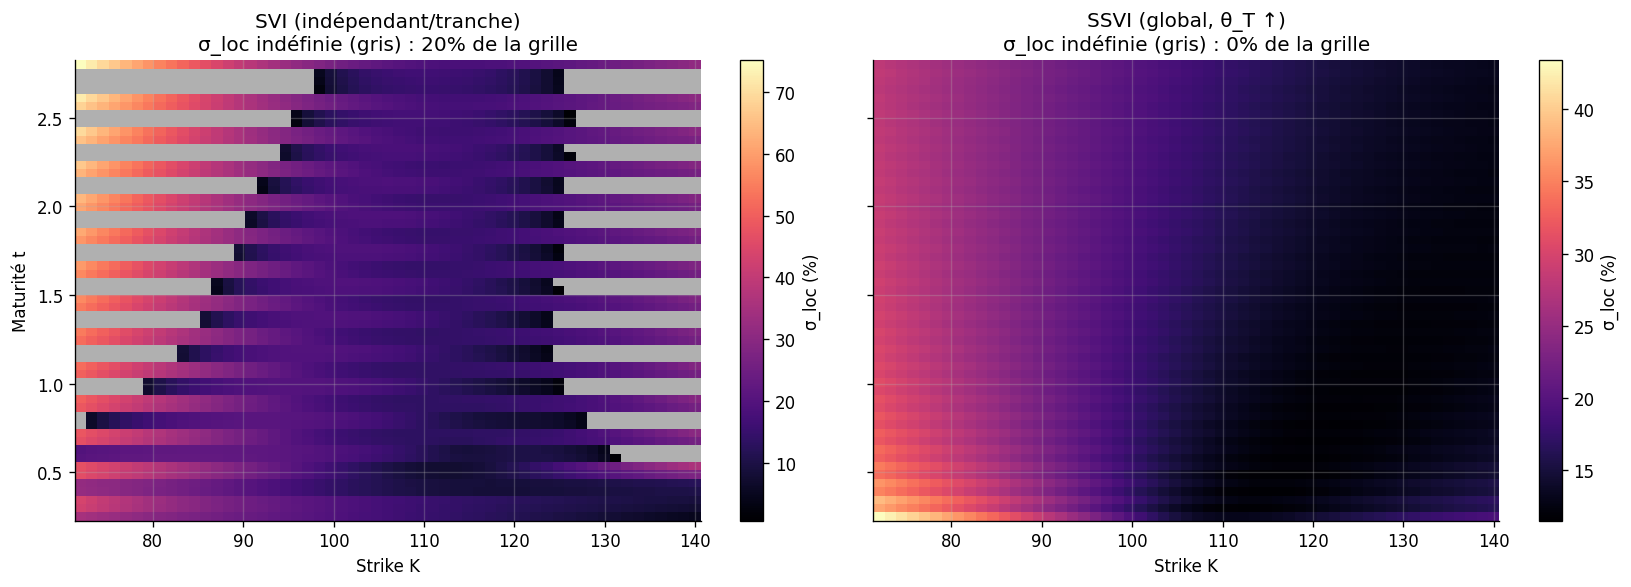

σ_loc indéfinie (NaN / arbitrage)  ->  SVI : 20%   SSVI : 0%


In [5]:
# Surface 'stressée' : maturités densifiées + perturbation d'AILE alternée par tranche.
# (déterministe : les ailes de tranches adjacentes se croisent -> ∂_T w < 0 garanti pour SVI ;
#  l'ATM est laissé intact, donc la structure θ_T reste croissante.)
dense_days = list(range(60, 1100, 35))            # ~30 maturités rapprochées
smiles_stress = []
for i, d in enumerate(dense_days):
    T = DC.year_fraction(REF, in_days(d)); F = fwd.forward(T)
    c = [EuropeanOption(und, float(K), REF, in_days(d), OptionType.CALL) for K in strikes]
    iv = np.asarray(ivc.calculate_implied_vol(c, fourier.price(c, heston)))
    wing = ((strikes - F) / F) ** 2
    iv = iv + 0.02 * (wing / wing.max()) * (-1) ** i   # bosse d'aile alternée (±2 pts de vol)
    smiles_stress.append(VolSmile(strikes, iv, LogLinearInterpolator1D(), in_days(d), AbsoluteStrike()))

# theta_T de SSVI : structure ATM PROPRE (monotone) — le bruit reste dans les tranches/ailes,
# pas dans la structure par terme (une ThetaCurve non monotone serait rejetée à la construction).
mats_stress = [DC.year_fraction(REF, in_days(d)) for d in dense_days]
theta_pillars = []
for d, T in zip(dense_days, mats_stress):
    atm = EuropeanOption(und, float(fwd.forward(T)), REF, in_days(d), OptionType.CALL)
    sig_atm = float(ivc.calculate_implied_vol([atm], fourier.price([atm], heston))[0])
    theta_pillars.append(sig_atm ** 2 * T)

# SVI (indépendant par tranche) vs SSVI (global, theta_T croissante).
import warnings
with warnings.catch_warnings():   # calibration sous stress : SLSQP peut clipper aux bornes
    warnings.simplefilter('ignore')
    surf_svi_s = VolSurface(smiles_stress, REF, DC, SVIInterpolator(fwd), forward_curve=fwd)
    surf_svi_s.calibrate_interpolator()
    tc_s = ThetaCurve(mats_stress, theta_pillars, LogLinearInterpolator1D())
    surf_ssvi_s = VolSurface(smiles_stress, REF, DC, SSVIInterpolator(fwd, tc_s), forward_curve=fwd)
    surf_ssvi_s.calibrate_interpolator()

lv_s = LocalVolModel(disc)
Kg = np.linspace(72, 140, 55)
Tg = np.linspace(0.25, 2.8, 55)

def sigma_loc_grid(surf):
    Z = np.full((len(Tg), len(Kg)), np.nan)
    with np.errstate(invalid='ignore'):
        for i, t in enumerate(Tg):
            try:
                Z[i, :] = lv_s.sigma_loc(Kg, float(t), surf, fwd)
            except ValueError:
                pass  # dénominateur <= 0 (arb papillon) -> ligne laissée NaN
    return Z

Z_svi = sigma_loc_grid(surf_svi_s)
Z_ssvi = sigma_loc_grid(surf_ssvi_s)
frac_svi = np.mean(~np.isfinite(Z_svi)) * 100
frac_ssvi = np.mean(~np.isfinite(Z_ssvi)) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, Z, name, frac in ((axes[0], Z_svi, 'SVI (indépendant/tranche)', frac_svi),
                          (axes[1], Z_ssvi, 'SSVI (global, θ_T ↑)', frac_ssvi)):
    ax.set_facecolor('#b0b0b0')            # les zones NaN (arbitrage) apparaissent en gris
    im = ax.pcolormesh(Kg, Tg, np.ma.masked_invalid(Z*100), cmap='magma', shading='auto')
    ax.set_title(f'{name}\nσ_loc indéfinie (gris) : {frac:.0f}% de la grille')
    ax.set_xlabel('Strike K'); fig.colorbar(im, ax=ax, label='σ_loc (%)')
axes[0].set_ylabel('Maturité t')
plt.tight_layout(); plt.show()
print(f"σ_loc indéfinie (NaN / arbitrage)  ->  SVI : {frac_svi:.0f}%   SSVI : {frac_ssvi:.0f}%")

Sur une surface bruitée et densifiée en maturité, **SVI** (tranches indépendantes,
$w$ linéaire en $T$) laisse apparaître des **trous** où $\sigma_{\rm loc}$ est indéfinie (c'est notre interoplateur qui interdit les arbitrages
calendaire $\partial_T w<0$ ou papillon $\partial_{KK}w<0$). **SSVI**, dont la structure $\theta_T$ est
strictement croissante et la contrainte papillon $\eta(1+|\rho|)\le 2$ imposée, reste **définie
partout**. C'est l'argument décisif pour préférer une paramétrisation **sans arbitrage** dès qu'on veut
en extraire une vol locale robuste.

*(Pour la suite, on revient à la surface propre (9 maturités, SVI) — dérivées analytiques excellentes
en strike, structure par terme lisse.)*

### 2.6 Mise en garde : le plancher numérique de la surface (rappel du notebook 05)

La surface vient d'un **pricing Fourier** (Carr-Madan), qui possède un **plancher numérique** (cf.
notebook 05) : les options profondément OTM à **courte maturité** valent quasi zéro (plusieurs
$\sigma\sqrt{T}$ hors de la monnaie), *sous* le plancher de la FFT → prix parfois **négatifs** et
**vols implicites aberrantes** dans les ailes courtes. L'amortissement **$\alpha$** abaisse ce plancher
(α=1.5 → ~2e-7 ; α=2.0 (défaut) → ~4e-10 ; α=2.5 → ~1e-12), mais ces options restent *génuinement* sans
valeur : leur IV n'a aucun sens. En production on **borne les strikes par maturité** (bande $\propto
\sigma\sqrt{T}$). Ici on conserve une plage large [60, 160] car elle **couvre la portée du Monte-Carlo**
(la diffusion ne consulte jamais les ailes courtes profondes) — on garde simplement en tête que le
**coin court-terme × aile de la surface est peu fiable**.

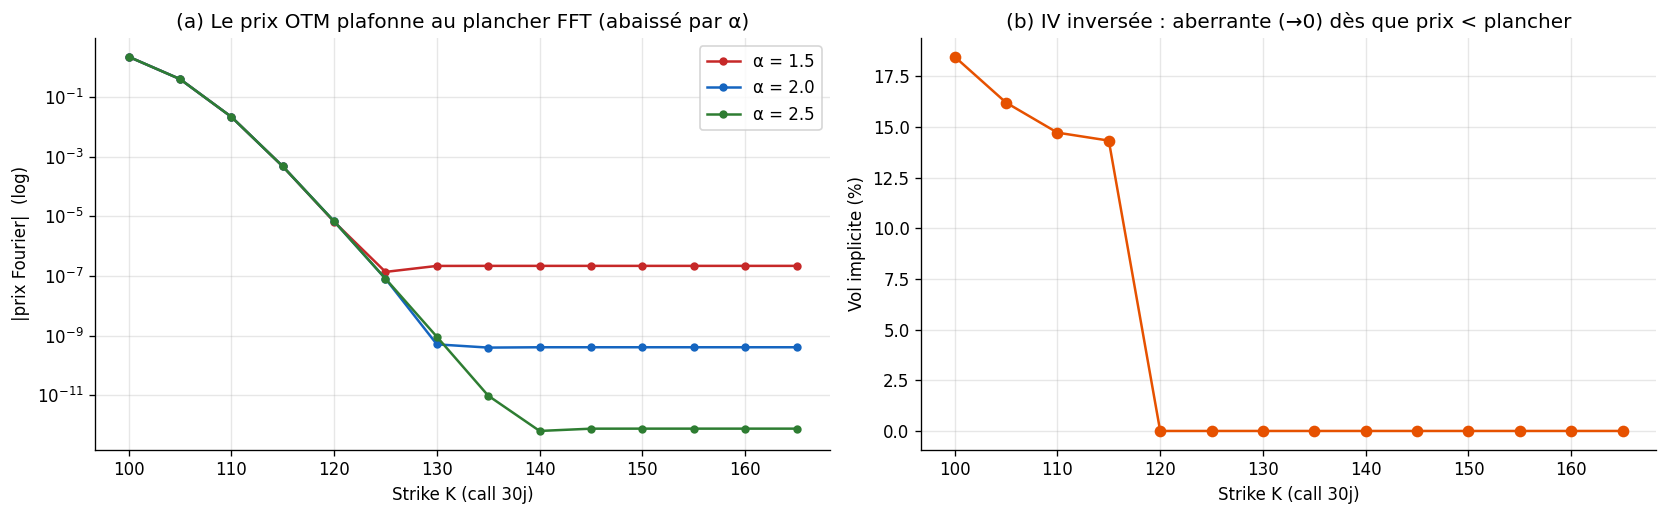

Prix Fourier des 3 derniers strikes (α=2.0) : [-4.05e-10 -4.05e-10 -4.05e-10]


In [6]:
# Démo du plancher : calls 30j de plus en plus OTM, prix Fourier selon α, puis IV inversée.
import warnings
Kw = np.linspace(100, 165, 14)
cw = [EuropeanOption(und, float(K), REF, in_days(30), OptionType.CALL) for K in Kw]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
for a, c in [(1.5, C_MKT), (2.0, C_IMP), (2.5, C_ACC)]:
    px = np.abs(np.asarray(FourierCarrMadanEngine(n=12, alpha=a).price(cw, heston)))
    ax[0].semilogy(Kw, np.maximum(px, 1e-18), 'o-', color=c, ms=4, label=f'α = {a}')
ax[0].set_xlabel('Strike K (call 30j)'); ax[0].set_ylabel('|prix Fourier|  (log)')
ax[0].set_title('(a) Le prix OTM plafonne au plancher FFT (abaissé par α)'); ax[0].legend()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    iv = np.asarray(ivc.calculate_implied_vol(cw, FourierCarrMadanEngine(n=12).price(cw, heston)))
ax[1].plot(Kw, iv * 100, 'o-', color=C_LOC)
ax[1].set_xlabel('Strike K (call 30j)'); ax[1].set_ylabel('Vol implicite (%)')
ax[1].set_title('(b) IV inversée : aberrante (→0) dès que prix < plancher')
plt.tight_layout(); plt.show()
print('Prix Fourier des 3 derniers strikes (α=2.0) :',
      np.array2string(np.asarray(fourier.price(cw[-3:], heston)), formatter={'float': lambda x: f'{x:.2e}'}))

## 3. Extraction de la vol locale & propriétés

### 3.1 $\sigma_{\rm loc}(K,t)$ vs $\sigma_{\rm impl}(K,T)$
Deux lectures de la **même** surface :
- $\sigma_{\rm impl}(K,T)$ : vol **moyenne** (sur $[0,T]$) qui price l'option de strike $K$ ;
- $\sigma_{\rm loc}(K,t)$ : vol **instantanée** au point $(S=K,\,t)$.

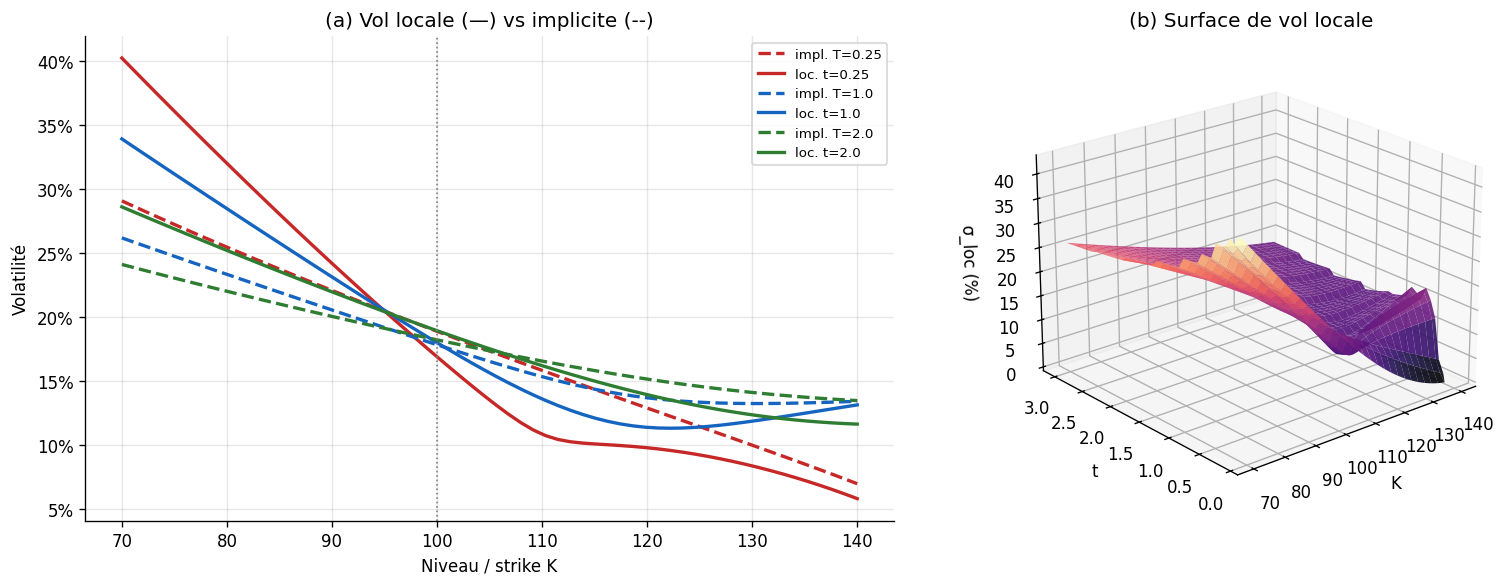

In [7]:
K_grid = np.linspace(70, 140, 60)
t_slices = [0.25, 1.0, 2.0]

fig = plt.figure(figsize=(14, 5))
ax = fig.add_subplot(1, 2, 1)
with np.errstate(invalid='ignore'):
    for t, c in zip(t_slices, [C_MKT, C_IMP, C_ACC]):
        ax.plot(K_grid, surface.sigma(K_grid, t)*100, color=c, lw=2, ls='--', label=f'impl. T={t}')
        ax.plot(K_grid, lv.sigma_loc(K_grid, t, surface, fwd)*100, color=c, lw=2, label=f'loc. t={t}')
ax.axvline(S0, color='grey', ls=':', lw=1)
ax.set_xlabel('Niveau / strike K'); ax.set_ylabel('Volatilité')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('(a) Vol locale (—) vs implicite (--)'); ax.legend(fontsize=8)

ax = fig.add_subplot(1, 2, 2, projection='3d')
KK, TT = np.meshgrid(K_grid, np.linspace(0.1, 3.0, 40))
with np.errstate(invalid='ignore'):
    ZZ = np.array([lv.sigma_loc(K_grid, float(t), surface, fwd) for t in TT[:, 0]]) * 100
ax.plot_surface(KK, TT, ZZ, cmap='magma', alpha=.9, linewidth=0)
ax.set_xlabel('K'); ax.set_ylabel('t'); ax.set_zlabel('σ_loc (%)')
ax.set_title('(b) Surface de vol locale'); ax.view_init(elev=22, azim=-130)
plt.tight_layout(); plt.show()

### 3.2 La règle du « facteur ~2 » sur le skew court terme
Près de la monnaie et à courte maturité, le **skew de vol locale vaut environ le double du skew de vol
implicite** :
$$\partial_K\sigma_{\rm loc}\big|_{\rm ATM}\approx 2\,\partial_K\sigma_{\rm impl}\big|_{\rm ATM}.$$
Intuition : la vol implicite est une *moyenne* ; pour **générer** une pente moyenne donnée, la vol
locale (instantanée) doit être **deux fois plus pentue**.

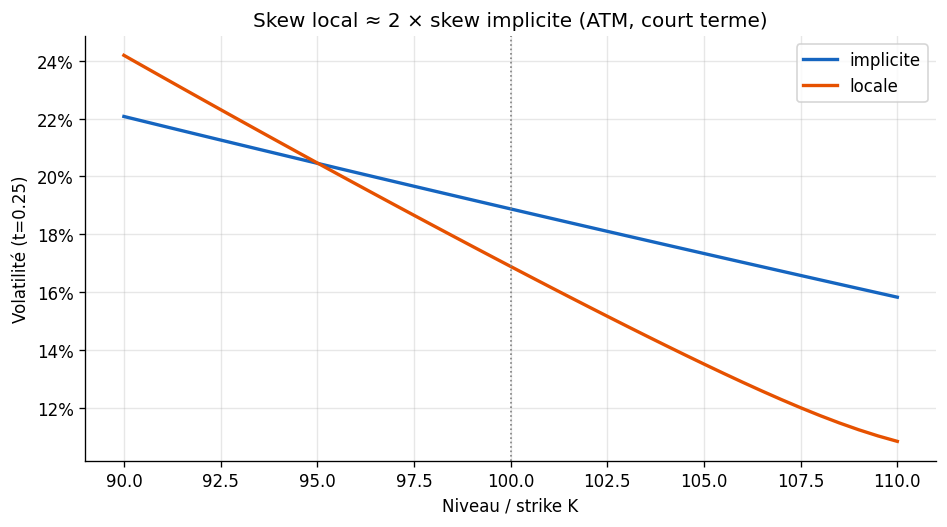

Skew implicite ATM : -0.312 %/pt
Skew local ATM     : -0.699 %/pt
Ratio local/implicite : 2.24   (≈ 2 attendu)


In [8]:
t = 0.25
Kc = np.linspace(90, 110, 41)
sig_imp = surface.sigma(Kc, t); sig_loc = lv.sigma_loc(Kc, t, surface, fwd)
i0 = int(np.argmin(np.abs(Kc - S0)))
skew_imp = np.gradient(sig_imp, Kc)[i0]; skew_loc = np.gradient(sig_loc, Kc)[i0]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(Kc, sig_imp*100, color=C_IMP, lw=2, label='implicite')
ax.plot(Kc, sig_loc*100, color=C_LOC, lw=2, label='locale')
ax.axvline(S0, color='grey', ls=':', lw=1)
ax.set_xlabel('Niveau / strike K'); ax.set_ylabel('Volatilité (t=0.25)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Skew local ≈ 2 × skew implicite (ATM, court terme)'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Skew implicite ATM : {skew_imp*100:.3f} %/pt')
print(f'Skew local ATM     : {skew_loc*100:.3f} %/pt')
print(f'Ratio local/implicite : {skew_loc/skew_imp:.2f}   (≈ 2 attendu)')

### 3.3 Vérification de Gyöngy : $\sigma_{\rm loc}^2(K,t)=\mathbb E[v_t\,|\,S_t=K]$
On simule le **Heston vrai** (qui a servi à générer la surface), on estime par **binning** l'espérance
de la variance instantanée $v_t$ conditionnellement au niveau $S_t=K$, et on la compare à la **variance
locale** $\sigma_{\rm loc}^2(K,t)$ extraite de la surface. Les deux doivent coïncider : c'est la
signification profonde de la vol locale (moyenne conditionnelle de la vraie variance).

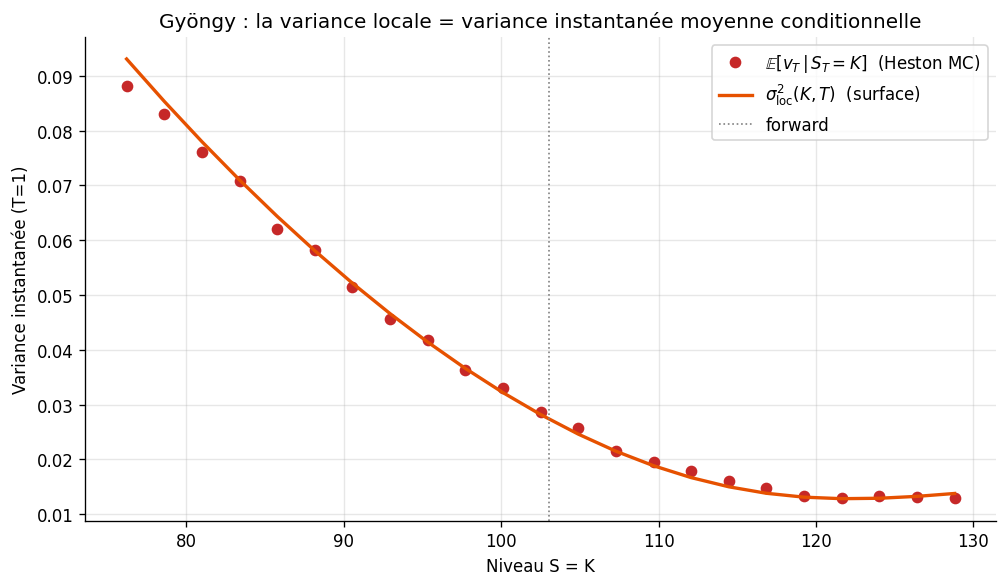

Écart relatif médian |E[v|S=K] - σ_loc²| / σ_loc² : 2.5 %


In [9]:
T_g = 1.0
disc_heston = heston.discretize(
    scheme=CIRDiscretizationSchemeEuler(EulerDiscretizationConvention.FULL_TRUNCATION), max_dt=0.02)
dummy = EuropeanOption(und, S0, REF, in_days(365), OptionType.CALL)
paths = MCEngine(80_000, seed=7).simulate_paths(dummy, disc_heston)
S_T = paths.spot_paths[:, -1]
v_T = paths.variance_paths[:, -1]

# E[v_T | S_T = K] par binning ; comparaison à sigma_loc^2 (surface)
edges = np.linspace(75, 130, 24)
centers = 0.5 * (edges[:-1] + edges[1:])
idx = np.digitize(S_T, edges) - 1
Ev, Kok = [], []
for b in range(len(centers)):
    m = idx == b
    if m.sum() > 200:
        Ev.append(v_T[m].mean()); Kok.append(centers[b])
Ev, Kok = np.array(Ev), np.array(Kok)
sig_loc_sq = lv.sigma_loc(Kok, T_g, surface, fwd) ** 2

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(Kok, Ev, 'o', color=C_MKT, ms=6, label=r'$\mathbb{E}[v_T\,|\,S_T=K]$  (Heston MC)')
ax.plot(Kok, sig_loc_sq, '-', color=C_LOC, lw=2, label=r'$\sigma_{\rm loc}^2(K,T)$  (surface)')
ax.axvline(fwd.forward(T_g), color='grey', ls=':', lw=1, label='forward')
ax.set_xlabel('Niveau S = K'); ax.set_ylabel('Variance instantanée (T=1)')
ax.set_title('Gyöngy : la variance locale = variance instantanée moyenne conditionnelle')
ax.legend()
plt.tight_layout(); plt.show()
print('Écart relatif médian |E[v|S=K] - σ_loc²| / σ_loc² :',
      round(float(np.median(np.abs(Ev - sig_loc_sq) / sig_loc_sq)) * 100, 1), '%')

L'espérance conditionnelle simulée (points) et la variance locale extraite de la surface (ligne)
se **superposent** : la vol locale de Dupire *est* la variance instantanée du vrai modèle, moyennée à
niveau de spot fixé. C'est aussi pourquoi, sur un **exotique** sensible à la *dynamique* de la vol (et
pas seulement à sa moyenne conditionnelle), vol locale et Heston peuvent **diverger** — cf. notebook 07.

## 4. Pricing par Monte-Carlo (schéma d'Euler)

### 4.1 Le schéma
On simule la SDE en **log** par Euler, la vol locale étant évaluée au **début** de chaque pas
(schéma non-anticipatif) :
$$
S_{t+\Delta t}=S_t\,\frac{F_{t+\Delta t}}{F_t}\,
\exp\!\Big(-\tfrac12\,\sigma_{\rm loc}^2(S_t,t)\,\Delta t+\sigma_{\rm loc}(S_t,t)\sqrt{\Delta t}\,Z\Big),
\quad Z\sim\mathcal N(0,1).
$$
Point crucial : $\sigma_{\rm loc}$ dépend de $(S_t,t)$ **le long du chemin**. Il faut donc un **pas de
temps fin** — un seul pas de 0 à $T$ (le défaut d'une européenne) écraserait toute la structure locale.
On enrichit donc la grille de simulation.

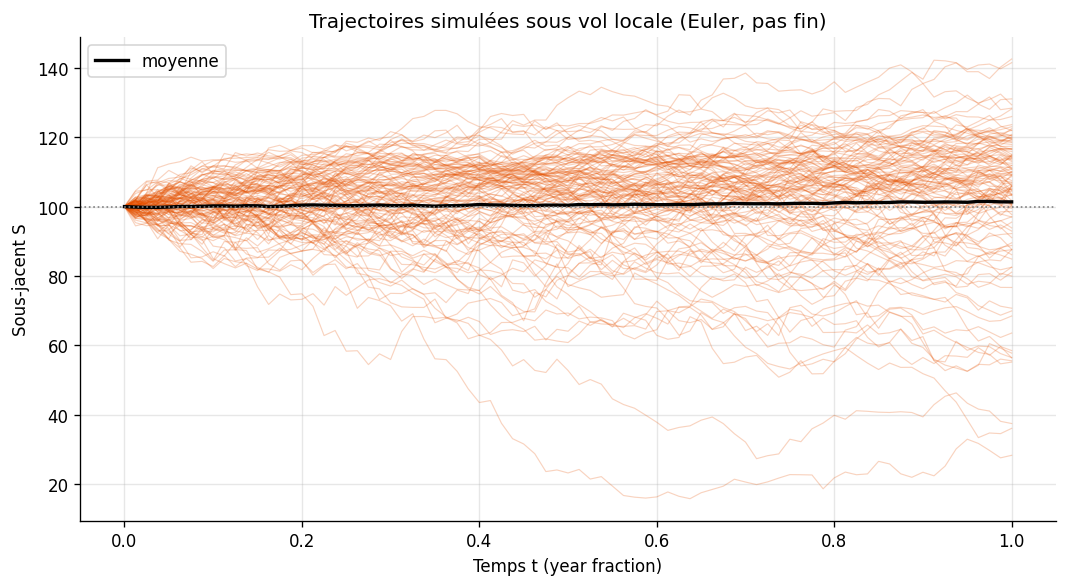

In [10]:
# Instrument à grille fine : call européen simulé en n_steps sous-pas (payoff call hérité).
class DenseCall(EuropeanOption):
    def __init__(self, *a, n_steps=80, **k):
        super().__init__(*a, **k); self._n = n_steps
    def simulation_times(self, reference_date, day_count_convention):
        T = day_count_convention.year_fraction(reference_date, self.maturity_date)
        return list(np.linspace(T/self._n, T, self._n))

# Quelques trajectoires de vol locale (pour visualiser la diffusion)
viz_call = DenseCall(und, S0, REF, in_days(365), OptionType.CALL, n_steps=80)
viz = MCEngine(400, seed=1).simulate_paths(viz_call, lv)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(viz.times, viz.spot_paths[:120].T, color=C_LOC, alpha=0.25, lw=0.7)
ax.plot(viz.times, viz.spot_paths.mean(axis=0), color='black', lw=2, label='moyenne')
ax.axhline(S0, color='grey', ls=':', lw=1)
ax.set_xlabel('Temps t (year fraction)'); ax.set_ylabel('Sous-jacent S')
ax.set_title('Trajectoires simulées sous vol locale (Euler, pas fin)'); ax.legend()
plt.tight_layout(); plt.show()

### 4.2 Convergence vers le prix de référence
La référence est le prix **Fourier** de l'ATM 1 an sous le Heston vrai (quasi-exact). On fait croître
$N$ : le prix MC-LV converge vers la référence dans un IC qui **rétrécit en $1/\sqrt N$**.

> **Subtilité importante (numérateur de Dupire).** Le numérateur $\partial_T w$ de la formule de
> Gatheral est pris à **log-moneyness $y=\ln(K/F_T)$ fixe**, *pas* à strike $K$ fixe. Comme le strike
> qui garde $y$ constant **suit le forward**, on a
> $\partial_T w|_y = \partial_T w|_K + \mu\,\partial_y w$ avec $\mu = d\ln F/dt = r-q$. Omettre le
> terme $\mu\,\partial_y w$ biaise la vol locale **dès que $r-q\neq 0$** (biais $\propto (r-q)\times$
> skew, nul sur surface plate) — et ce biais ne disparaît **ni** en raffinant le pas **ni** en
> augmentant $N$. `LocalVolModel` applique la correction ; le MC converge donc **bien** vers la
> référence (et non vers une valeur décalée).

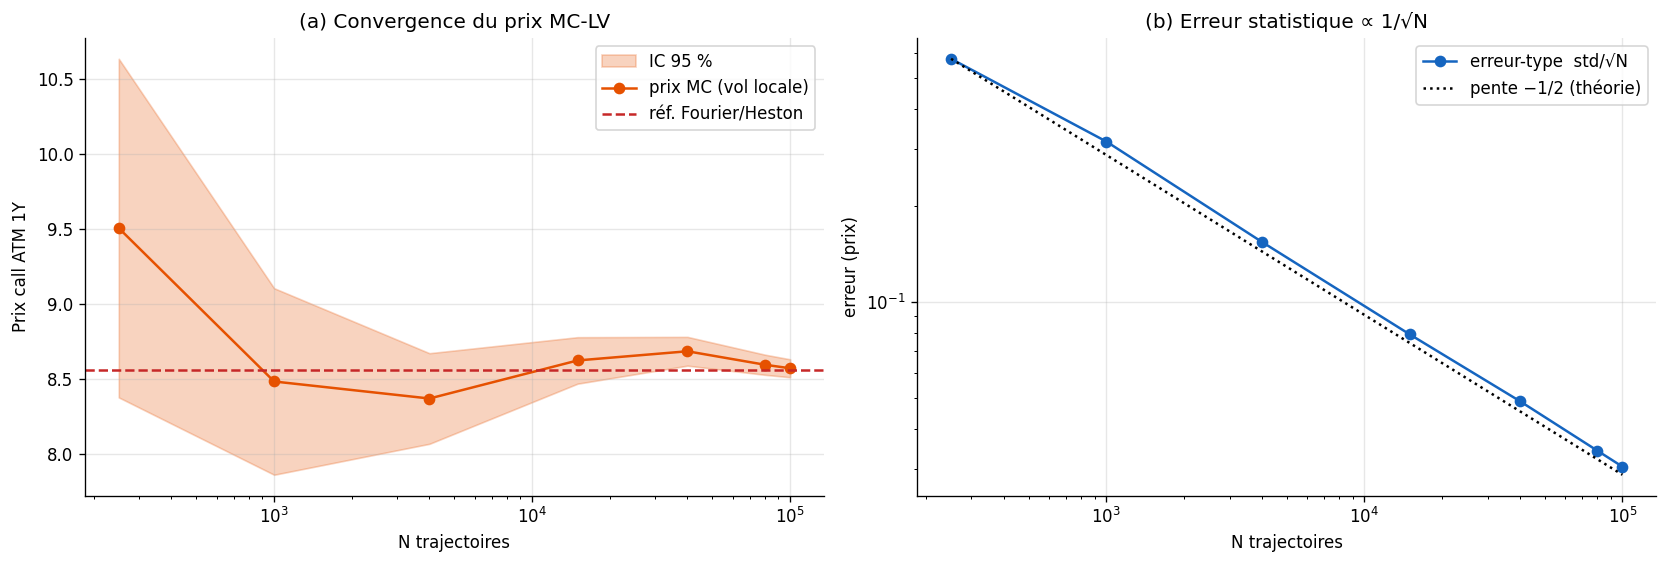

Prix réf. Fourier/Heston = 8.5618   |   prix MC-LV (N max) = 8.5733
Pente log(erreur-type) vs log(N) = -0.495   (théorie : -0.5)


In [11]:
atm_call = EuropeanOption(und, S0, REF, in_days(365), OptionType.CALL)
px_ref = fourier.price([atm_call], heston)[0]     # référence Fourier/Heston (quasi-exact)

Ns = np.array([250, 1000, 4000, 15000, 40000, 80000, 100000])
prices, ses = [], []
for N in Ns:
    payoff = lv.simulate(DenseCall(und, S0, REF, in_days(365), OptionType.CALL, n_steps=150),
                         int(N), rng=np.random.default_rng(42))
    prices.append(payoff.mean()); ses.append(payoff.std(ddof=1)/np.sqrt(N))
prices, ses = np.array(prices), np.array(ses)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].fill_between(Ns, prices-1.96*ses, prices+1.96*ses, alpha=0.25, color=C_LOC, label='IC 95 %')
ax[0].plot(Ns, prices, 'o-', color=C_LOC, label='prix MC (vol locale)')
ax[0].axhline(px_ref, color=C_MKT, ls='--', label='réf. Fourier/Heston')
ax[0].set_xscale('log'); ax[0].set_xlabel('N trajectoires'); ax[0].set_ylabel('Prix call ATM 1Y')
ax[0].set_title('(a) Convergence du prix MC-LV'); ax[0].legend()

ax[1].loglog(Ns, ses, 'o-', color=C_IMP, label='erreur-type  std/√N')
ax[1].loglog(Ns, ses[0]*np.sqrt(Ns[0]/Ns), 'k:', label='pente −1/2 (théorie)')
ax[1].set_xlabel('N trajectoires'); ax[1].set_ylabel('erreur (prix)')
ax[1].set_title('(b) Erreur statistique ∝ 1/√N'); ax[1].legend()
plt.tight_layout(); plt.show()
slope = np.polyfit(np.log(Ns), np.log(ses), 1)[0]
print(f'Prix réf. Fourier/Heston = {px_ref:.4f}   |   prix MC-LV (N max) = {prices[-1]:.4f}')
print(f'Pente log(erreur-type) vs log(N) = {slope:.3f}   (théorie : -0.5)')

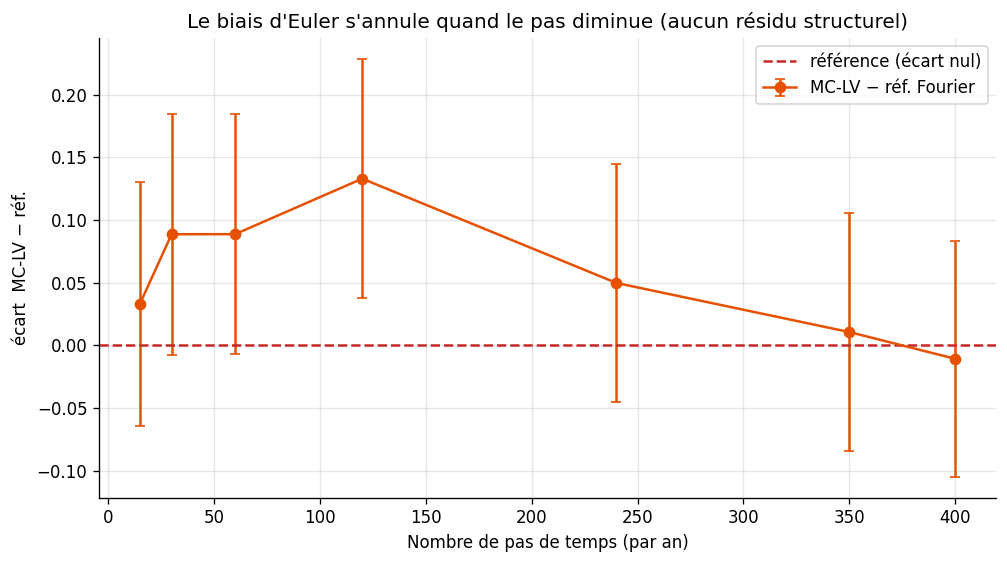

écart (n_steps=240) = -0.0108   (≈ bruit MC : ±0.0941) -> la LV reprice la référence


In [12]:
# Biais de discrétisation : N grand fixé, on raffine le pas de temps (n_steps croissant).
N_bias = 40_000
steps_list = [15, 30, 60, 120, 240, 350, 400 ]
bias, bias_se = [], []
for ns in steps_list:
    payoff = lv.simulate(DenseCall(und, S0, REF, in_days(365), OptionType.CALL, n_steps=ns),
                         N_bias, rng=np.random.default_rng(42))
    bias.append(payoff.mean() - px_ref); bias_se.append(payoff.std(ddof=1)/np.sqrt(N_bias))
bias, bias_se = np.array(bias), np.array(bias_se)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.errorbar(steps_list, bias, yerr=1.96*bias_se, fmt='o-', capsize=3, color=C_LOC,
            label='MC-LV − réf. Fourier')
ax.axhline(0, color=C_MKT, ls='--', label='référence (écart nul)')
ax.set_xlabel('Nombre de pas de temps (par an)'); ax.set_ylabel('écart  MC-LV − réf.')
ax.set_title("Le biais d'Euler s'annule quand le pas diminue (aucun résidu structurel)")
ax.legend()
plt.tight_layout(); plt.show()
print('écart (n_steps=240) =', round(float(bias[-1]), 4),
      f'  (≈ bruit MC : ±{1.96*bias_se[-1]:.4f}) -> la LV reprice la référence')

### 4.3 La vol locale **reprice** la surface
Par construction (Dupire), simuler sous $\sigma_{\rm loc}$ et repricer les vanilles **redonne le smile**.
Astuce : un payoff $=S_T$ par chemin reprice **tous** les strikes en **une** simulation. On price chaque
point par l'option **OTM** (call si $K\ge F$, put sinon) : leur vega est correct, alors qu'un call
profondément ITM a un vega faible qui **amplifie le bruit** d'inversion en vol.

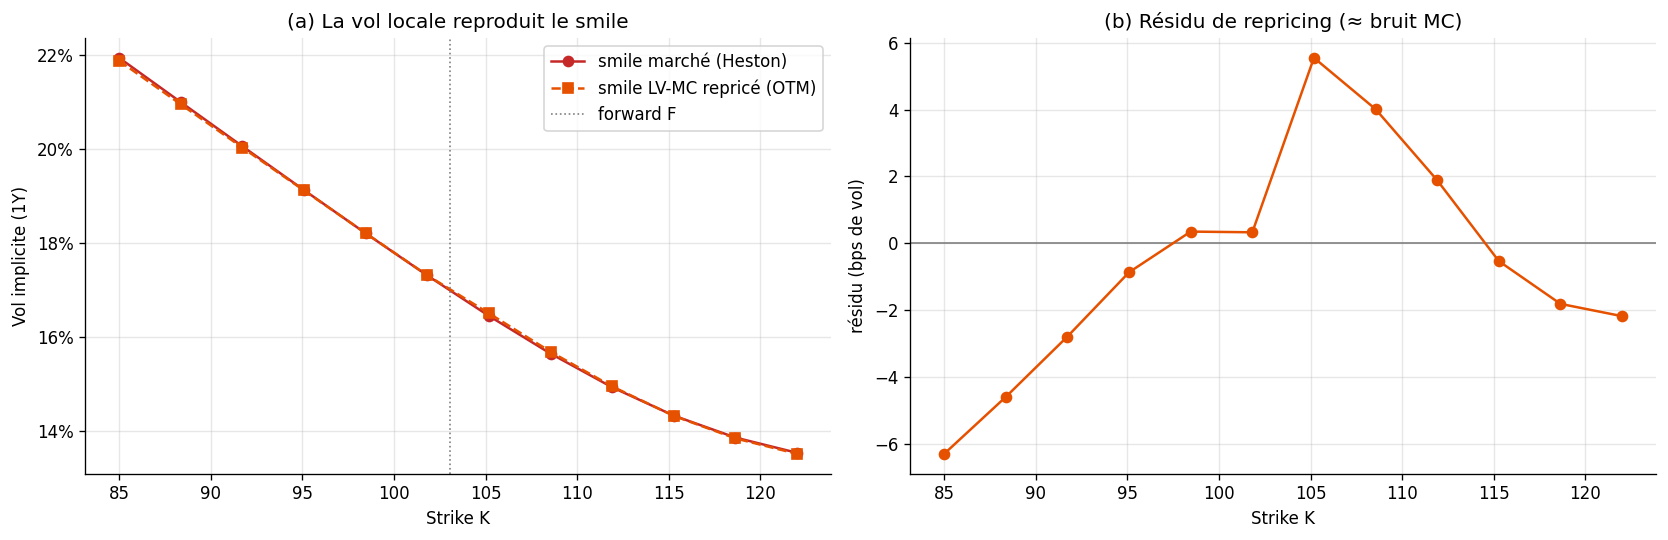

Résidu de vol max : 6.3 bps (≈ bruit MC)


In [13]:
class TerminalSpots(EuropeanOption):
    def __init__(self, *a, n_steps=120, **k):
        super().__init__(*a, **k); self._n = n_steps
    def simulation_times(self, reference_date, day_count_convention):
        T = day_count_convention.year_fraction(reference_date, self.maturity_date)
        return list(np.linspace(T/self._n, T, self._n))
    def payoff(self, paths):
        return paths[:, -1]

T1 = 365/365.0; df1 = disc.discount(T1); F1 = fwd.forward(T1)
K_re = np.linspace(85, 122, 12)
otm = K_re >= F1                                    # OTM : call si K>=F, put sinon
opts = [EuropeanOption(und, float(K), REF, in_days(365),
                       OptionType.CALL if o else OptionType.PUT) for K, o in zip(K_re, otm)]
# prix marché OTM : call Fourier ; put par parité  P = C - df·(F - K)
call_mkt = np.asarray(fourier.price(
    [EuropeanOption(und, float(K), REF, in_days(365), OptionType.CALL) for K in K_re], heston))
px_mkt = np.where(otm, call_mkt, call_mkt - df1 * (F1 - K_re))
iv_mkt = np.asarray(ivc.calculate_implied_vol(opts, px_mkt))

# UNE simulation -> S_T ; on price calls et puts OTM en vectoriel
ST = lv.simulate(TerminalSpots(und, S0, REF, in_days(365), OptionType.CALL, n_steps=600),
                 400_000, rng=np.random.default_rng(2024)) / df1
payoff = np.where(otm, np.maximum(ST[:, None] - K_re[None, :], 0.0),
                       np.maximum(K_re[None, :] - ST[:, None], 0.0))
px_lv = df1 * payoff.mean(axis=0)
iv_lv = np.asarray(ivc.calculate_implied_vol(opts, px_lv))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].plot(K_re, iv_mkt*100, 'o-', color=C_MKT, label='smile marché (Heston)')
ax[0].plot(K_re, iv_lv*100, 's--', color=C_LOC, label='smile LV-MC repricé (OTM)')
ax[0].axvline(F1, color='grey', ls=':', lw=1, label='forward F')
ax[0].set_xlabel('Strike K'); ax[0].set_ylabel('Vol implicite (1Y)')
ax[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax[0].set_title('(a) La vol locale reproduit le smile'); ax[0].legend()
ax[1].axhline(0, color='grey', lw=1)
ax[1].plot(K_re, (iv_lv-iv_mkt)*1e4, 'o-', color=C_LOC)
ax[1].set_xlabel('Strike K'); ax[1].set_ylabel('résidu (bps de vol)')
ax[1].set_title('(b) Résidu de repricing (≈ bruit MC)')
plt.tight_layout(); plt.show()
print('Résidu de vol max :', round(float(np.max(np.abs(iv_lv-iv_mkt)))*1e4, 1), 'bps (≈ bruit MC)')

## 5. Récapitulatif

- **Modèle.** La vol locale $\sigma_{\rm loc}(S,t)$ est l'**unique** diffusion *déterministe* à un
  facteur qui reprice une surface donnée ; elle s'en extrait par **Dupire/Gatheral**. Par Gyöngy, c'est
  la **variance instantanée moyenne conditionnelle** du vrai modèle, $\mathbb E[v_t\,|\,S_t=K]$.
- **Calibration.** Dupire est un **quotient de dérivées** ($\partial_{KK}w$ = densité,
  $\partial_T w$ = calendaire). Les **différences finies** amplifient le bruit ($\sim 1/h^2$) ; on
  préfère des interpolateurs **paramétriques à dérivées analytiques**. **SVI** excelle en strike mais
  n'a **aucune garantie calendaire** (tranches indépendantes, $w$ linéaire en $T$) ; **SSVI** est
  **sans arbitrage par construction** (papillon $\eta(1+|\rho|)\le 2$, $\theta_T$ croissante) — plus sûr
  pour une vol locale robuste.
- **Pricing.** Simulation **Euler** log, vol évaluée le long du chemin (pas fin requis). Le prix MC-LV
  **converge** vers la référence (erreur $\propto 1/\sqrt N$, biais d'Euler $\to 0$ quand le pas diminue)
  et la LV **reprice** le smile au **bruit MC** près — conformément à la garantie de Dupire. Un point
  subtil : le numérateur $\partial_T w$ se prend à **log-moneyness fixe** (sinon biais $\propto
  (r-q)\times$ skew, §4.2). Enfin, la surface étant issue d'un pricing **Fourier**, ses ailes
  court-terme sont peu fiables (plancher FFT, §2.6).

**Suite — notebook 07.** Deux modèles calés sur la **même** surface (vol locale *vs* Heston) peuvent
**diverger sur un exotique** : c'est la question *sticky strike* vs *sticky smile*, et l'impact sur le
prix et le hedging d'options path-dependent.